In [1]:
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from collections import defaultdict
import seaborn as sns
with warnings.catch_warnings():
    warnings.simplefilter("ignore", FutureWarning)
    if not hasattr(np, "bool"):
        np.bool = np.bool_
from qpython import qconnection
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from scipy.stats import spearmanr
from statsmodels.tsa.stattools import adfuller



In [2]:

HOST = "hfm.princeton.edu"
PORT = 6007
RETRY_PORT = 6009
RETRY_INTERVAL = 5


def open_kdb_connection(host=HOST, port=RETRY_PORT):
    while True:
        try:
            q = qconnection.QConnection(
                host=host,
                port=port,
                pandas=False,
            )
            q.open()
            return q
        except Exception as e:
            print(f"Connection failed: {e}")
            time.sleep(RETRY_INTERVAL)


def safe_execute(db, query):
    try:
        return db(query), db
    except Exception:
        try:
            db.close()
        except Exception:
            pass
        db = open_kdb_connection()
        return db(query), db

try:
    db = qconnection.QConnection(
        host=HOST,
        port=PORT,
        pandas=False,
    )
    db.open()
except Exception:
    db = open_kdb_connection()


In [4]:
def to_pandas(x):
    """Convert common kdb/PyKX/qpython outputs to a pandas DataFrame."""
    # If safe_execute returns (result, meta), unwrap
    if isinstance(x, tuple):
        x = x[0]

    if isinstance(x, pd.DataFrame):
        return x

    if isinstance(x, (np.recarray, np.ndarray)) and getattr(x, "dtype", None) is not None and x.dtype.names:
        return pd.DataFrame.from_records(x)

    if isinstance(x, dict):
        return pd.DataFrame(x)

    return pd.DataFrame(x)

def add_only_A_B_M_signal(
    df_prices: pd.DataFrame,
    window: int = 60,
    eps: float = 1e-8,
    col_prefix: str = "",
) -> pd.DataFrame:
    df = df_prices.copy()
    tickers = list(df.columns)
    N = len(tickers)
    alpha = float(np.exp(-1.0 / window))
    z = df.values.astype(float)
    T = z.shape[0]

    A = np.zeros(N, dtype=float)
    B = np.zeros(N, dtype=float)
    M = np.zeros((N, N), dtype=float)

    A_hist = np.zeros((T, N))
    B_hist = np.zeros((T, N))
    M_hist = np.zeros((T, N, N))
    s_hist = np.zeros((T, N))

    pc1_hist = np.full(T, np.nan, dtype=float)
    pc2_hist = np.full(T, np.nan, dtype=float)

    prev_v1 = None
    prev_v2 = None

    for t in range(T):
        zt = z[t]
        mask = np.isfinite(zt).astype(float)

        A = alpha * A + mask * np.where(np.isfinite(zt), zt, 0.0)
        B = alpha * B + mask

        z_filled = np.where(np.isfinite(zt), zt, 0.0)
        M = alpha * M + np.outer(z_filled, z_filled)

        mu = A / np.maximum(B, eps)

        Cov = M / np.maximum(np.mean(B), eps) - np.outer(mu, mu)
        Cov = 0.5 * (Cov + Cov.T)

        diag = np.diag(Cov)
        diag = np.where(np.isfinite(diag), diag, eps)
        sigma = np.sqrt(np.maximum(diag, eps))

        vals, vecs = np.linalg.eigh(Cov)
        order = np.argsort(vals)[::-1]
        vecs = vecs[:, order]

        v1 = vecs[:, 0]
        v2 = vecs[:, 1] if N > 1 else np.full(N, np.nan)

        if prev_v1 is not None and np.dot(v1, prev_v1) < 0:
            v1 = -v1
        prev_v1 = v1.copy()

        if N > 1 and prev_v2 is not None and np.dot(v2, prev_v2) < 0:
            v2 = -v2
        if N > 1:
            prev_v2 = v2.copy()

        # standardized z for the signal reconstruction
        z_std = (np.where(np.isfinite(zt), zt, mu) - mu) / sigma

        # raw, non-normalized PC scores
        x_centered = np.where(np.isfinite(zt), zt, mu) - mu
        pc1_hist[t] = float(v1.T @ x_centered)
        if N > 1:
            pc2_hist[t] = float(v2.T @ x_centered)

        xi = float(v1.T @ z_std)
        z_hat = mu + (v1 * sigma) * xi
        s = z_hat - np.where(np.isfinite(zt), zt, z_hat)

        A_hist[t] = A
        B_hist[t] = B
        M_hist[t] = M
        s_hist[t] = s

    out = df.copy()

    for i, tk in enumerate(tickers):
        out[f"{col_prefix}A_{tk}"] = A_hist[:, i]
        out[f"{col_prefix}s_{tk}"] = s_hist[:, i]
        out[f"{col_prefix}B_{tk}"] = B_hist[:, i]

    for i, tki in enumerate(tickers):
        for j, tkj in enumerate(tickers):
            out[f"{col_prefix}M_{tki}_{tkj}"] = M_hist[:, i, j]

    out[f"{col_prefix}pc1"] = pc1_hist
    out[f"{col_prefix}pc2"] = pc2_hist

    return out



def attach_datetime_from_ns_index(df: pd.DataFrame, date_str: str) -> pd.DataFrame:
    """Index is ns since midnight; anchor to date_str."""
    td = pd.to_timedelta(df.index.astype("int64"), unit="ns")
    base = pd.to_datetime(date_str)
    out = df.copy()
    out.index = base + td
    out.index.name = "datetime"
    return out


def plot_asset(df: pd.DataFrame, tickers, colors):
    if isinstance(tickers, str):
        tickers = [tickers]
    if isinstance(colors, str):
        colors = [colors]
    if len(tickers) != len(colors):
        raise ValueError("tickers and colors must have the same length")
    if len(tickers) != 2:
        raise ValueError("plot_asset currently expects exactly two tickers for the OLS residual plot")

    t = df.index  # datetime index

    fig = plt.figure(figsize=(11, 9), facecolor="white")
    fig.text(0.05, 0.92, "Normalized time series and forecasts", fontsize=28, color="#d55e00")

    ax = fig.add_axes([0.07, 0.48, 0.88, 0.38])

    for ticker, color in zip(tickers, colors):
        p = df[ticker].astype(float)
        z_hat = (df[ticker] + df[f"s_{ticker}"]).astype(float)

        p0 = p.dropna().iloc[0]
        z0 = z_hat.dropna().iloc[0]
        p_norm = p / p0
        z_hat_norm = z_hat / z0

        ax.step(t, p_norm, where="post", linewidth=2.4, color=color, label=f"{ticker} (normalized price)")
        ax.step(t, z_hat_norm, where="post", linewidth=1.6, color=color, alpha=0.35, label=f"{ticker} forecast")

    # clean axes
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)

    ax.tick_params(axis="y", which="both", left=False, labelleft=False)

    ax.tick_params(axis="x", which="major", length=10, width=1.2, direction="out", labelsize=12)
    ax.xaxis.set_major_locator(mdates.HourLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

    # date annotation
    ax.text(
        0.98, 0.98, f"{t.min().date()}",
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize=14
    )

    # legend
    leg = ax.legend(loc="lower right", frameon=True, framealpha=1.0, fancybox=False, borderpad=0.8)
    leg.get_frame().set_edgecolor("black")
    leg.get_frame().set_linewidth(1.0)

    x_ticker, y_ticker = tickers[0], tickers[1]
    reg_df = df[[x_ticker, y_ticker]].astype(float).dropna()
    x = reg_df[x_ticker].values
    y = reg_df[y_ticker].values
    ols = sm.OLS(y, x).fit()
    beta = float(np.asarray(ols.params).squeeze())
    epsilon = reg_df[y_ticker] - beta * reg_df[x_ticker]

    ax_res = fig.add_axes([0.07, 0.12, 0.88, 0.22])
    ax_res.plot(epsilon.index, epsilon, color="black", linewidth=1.6, label=fr"$\epsilon_t = {y_ticker} - {beta:.4f}{x_ticker}$")
    ax_res.axhline(0.0, color="gray", linestyle="--", linewidth=1.0, alpha=0.8)

    for sp in ["top", "right"]:
        ax_res.spines[sp].set_visible(False)

    ax_res.tick_params(axis="x", which="major", length=10, width=1.2, direction="out", labelsize=12)
    ax_res.tick_params(axis="y", which="major", length=6, width=1.0, direction="out", labelsize=11)
    ax_res.xaxis.set_major_locator(mdates.HourLocator())
    ax_res.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax_res.set_title(f"OLS residuals for {y_ticker} = B x {x_ticker} + epsilon", fontsize=14)
    ax_res.set_ylabel("epsilon")
    ax_res.legend(loc="upper right", frameon=True, framealpha=1.0, fancybox=False)

    plt.show()



def run_oneday_pipeline(
    db,
    date_quotes: str = "2024.02.22",
    date_active: str = "2024.02.22",
    insts=("ES", "NQ"),
    window: int = 60,
    eps: float = 1e-8,
    make_scatter: bool = True,
):
    """
    End-to-end:
      1) query active symbols from kdb (top 8 by sum siz) on date_active
      2) pull 1-minute midprices for those syms on date_quotes
      3) apply symbol-specific price scaling
      4) compute EW stats + PCA-projection signal for ESH4,NQH4
      5) attach datetime index and plot each asset separately

    Returns:
      sym_active, df_midprice_all, df_dt, df_oneday
    """
    # ---- helpers (local, so function is self-contained) ----
    def _decode_syms(lst):
        return [s.decode() if isinstance(s, (bytes, bytearray)) else str(s) for s in lst]

    def _prefix(sym: str) -> str:
        s = sym.decode() if isinstance(sym, (bytes, bytearray)) else str(sym)
        return "".join(ch for ch in s if ch.isalpha())[:2]

    def _scale_for_sym(sym: str) -> float:
        pfx = _prefix(sym)
        if pfx == "CL":
            return 100.0
        elif pfx == "RB":
            return 10000.0
        elif pfx == "HO":
            return 10000.0
        elif pfx == "ES":
            return 100.0
        elif pfx == "NQ":
            return 100.0
        else:
            return 100.0

    # ---- 1) active symbols ----
    inst_list = "; ".join([f"`{x}" for x in insts])
    q_active = f"""
    8 sublist
    select v, sym
    from `v xdesc
      (select v: sum siz by sym
       from trade
       where date = {date_active},
             sym2inst[sym] in ({inst_list}))
    """
    res = safe_execute(db, q_active)
    df_res = to_pandas(res)

    if "sym" not in df_res.columns:
        raise ValueError("Active-symbol query did not return a 'sym' column.")

    sym_active = _decode_syms(df_res["sym"].tolist())
    print("Active symbols:", sym_active)

    # ---- 2) pull midprices ----
    df_midprice_all = None

    for sym in sym_active:
        q_mid = f"""
        aj[`time;
            ([] time: (0D00:00:00 + 0D00:01:00 * til 961));
            select midprice1: (last bid + last ask) % 2 by time
            from quote where date={date_quotes}, sym=`{sym}
        ]
        """
        raw = safe_execute(db, q_mid)
        df_sym = to_pandas(raw)

        if "time" not in df_sym.columns:
            raise ValueError(f"Midprice query for {sym} did not return 'time' column.")

        if "midprice1" in df_sym.columns:
            df_sym = df_sym.rename(columns={"midprice1": sym})
        elif sym not in df_sym.columns:
            raise ValueError(f"Midprice query for {sym} did not return 'midprice1' or '{sym}'.")

        df_midprice_all = (
            df_sym if df_midprice_all is None
            else df_midprice_all.merge(df_sym, on="time", how="left")
        )

    # ---- 3) symbol-specific scaling ----
    df_midprice_all = df_midprice_all.copy()
    for sym in sym_active:
        if sym in df_midprice_all.columns:
            scale = _scale_for_sym(sym)
            df_midprice_all[sym] = df_midprice_all[sym].astype(float) / scale
            print(f"{sym}: applied raw price scale 1/{scale}")

    # ---- 4) optional visualization ----
    if make_scatter:
        required_vis = ["ESH4", "NQH4"]
        if set(required_vis).issubset(df_midprice_all.columns):
            df_sc = df_midprice_all[["time"] + required_vis].copy().dropna()
            time_labels = (
                pd.Timestamp("2000-01-01")
                + pd.to_timedelta(df_sc["time"].astype("int64"), unit="ns")
            ).dt.strftime("%H:%M")
            cvals = np.arange(len(df_sc))

            plt.figure(figsize=(8, 6))
            plt.plot(
                df_sc["ESH4"],
                df_sc["NQH4"],
                alpha=0.35,
                linewidth=0.4,
            )
            plt.scatter(
                df_sc["ESH4"],
                df_sc["NQH4"],
                c=cvals,
                cmap="viridis",
                alpha=0.75,
                s=18,
            )
            cb = plt.colorbar()
            tick_idx = np.linspace(0, len(df_sc) - 1, min(6, len(df_sc)), dtype=int)
            cb.set_ticks(tick_idx)
            cb.set_ticklabels(time_labels.iloc[tick_idx])
            cb.set_label("Time")
            plt.grid(which="minor", visible=False)
            plt.title("ESH4 vs NQH4", fontsize=18, fontweight="bold", color="darkorange")
            plt.xlabel("ESH4")
            plt.ylabel("NQH4")
            plt.tight_layout()
            plt.show()

    # ---- 5) compute signal for ESH4/NQH4 ----
    required_cols = ["ESH4", "NQH4"]

    if not set(required_cols).issubset(df_midprice_all.columns):
        raise ValueError(f"Missing required columns: {required_cols}")

    data_one = df_midprice_all[["time"] + required_cols].copy().set_index("time")

    df_oneday = add_only_A_B_M_signal(data_one, window=window, eps=eps)

    # ---- 6) attach datetime + plot ----
    date_anchor = date_quotes.replace(".", "-")
    df_dt = attach_datetime_from_ns_index(df_oneday, date_anchor)

    plot_asset(df_dt, ["ESH4", "NQH4"], ["darkorange", "navy"])

    return sym_active, df_midprice_all, df_dt, df_oneday

Active symbols: ['ESH4', 'NQH4', 'ESM4', 'NQM4', 'ESU4', 'NQU4', 'ESZ4', 'NQZ4']
ESH4: applied raw price scale 1/100.0
NQH4: applied raw price scale 1/100.0
ESM4: applied raw price scale 1/100.0
NQM4: applied raw price scale 1/100.0
ESU4: applied raw price scale 1/100.0
NQU4: applied raw price scale 1/100.0
ESZ4: applied raw price scale 1/100.0
NQZ4: applied raw price scale 1/100.0


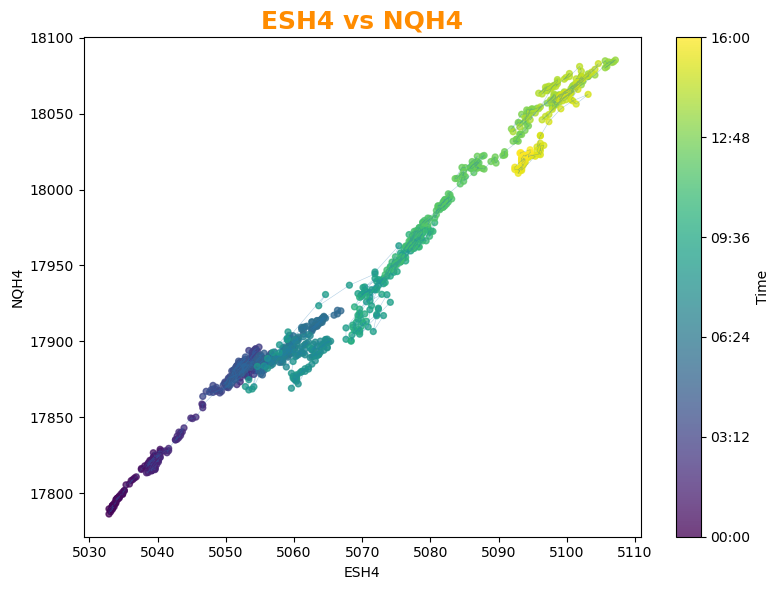

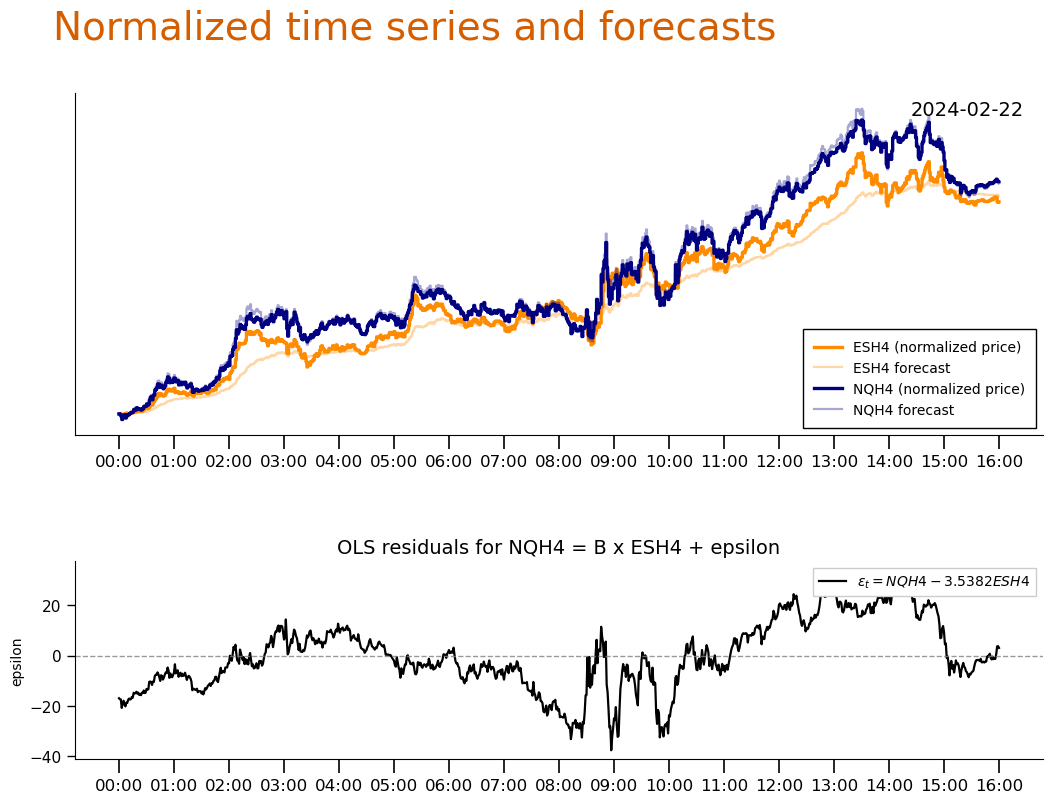

In [5]:
sym_active, df_midprice_all, df_dt, df_oneday=run_oneday_pipeline(db)

# Using More data

In [147]:
def plot_asset_trading_time(df: pd.DataFrame, tickers, colors):
    if isinstance(tickers, str):
        tickers = [tickers]
    if isinstance(colors, str):
        colors = [colors]
    if len(tickers) != len(colors):
        raise ValueError("tickers and colors must have the same length")
    if len(tickers) != 2:
        raise ValueError("plot_asset_trading_time currently expects exactly two tickers for the OLS residual plot")

    df = df.sort_index()

    # trading-time index
    x = np.arange(len(df))

    # daily boundaries for the trading-time axis
    dates = df.index.normalize()
    unique_dates, date_positions = np.unique(dates, return_index=True)
    unique_dates = pd.to_datetime(unique_dates)

    fig = plt.figure(figsize=(11, 9), facecolor="white")
    fig.text(0.05, 0.92, "Normalized time series and forecasts", fontsize=28, color="#d55e00")

    ax = fig.add_axes([0.07, 0.48, 0.88, 0.38])

    for ticker, color in zip(tickers, colors):
        p = df[ticker].astype(float)
        z_hat = (df[ticker] + df[f"s_{ticker}"]).astype(float)

        p0 = p.dropna().iloc[0]
        z0 = z_hat.dropna().iloc[0]
        p_norm = (p / p0).values
        z_hat_norm = (z_hat / z0).values

        ax.step(x, p_norm, where="post", linewidth=2.4, color=color, label=f"{ticker} (normalized price)")
        ax.step(x, z_hat_norm, where="post", linewidth=1.6, color=color, alpha=0.35, label=f"{ticker} forecast")

    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)

    ax.tick_params(axis="y", which="both", left=False, labelleft=False)
    ax.tick_params(axis="x", which="major", length=10, width=1.2, direction="out", labelsize=12)
    ax.set_xticks(date_positions)
    ax.set_xticklabels([d.strftime("%m-%d") for d in unique_dates], rotation=45)

    leg = ax.legend(loc="lower right", frameon=True, framealpha=1.0, fancybox=False, borderpad=0.8)
    leg.get_frame().set_edgecolor("black")
    leg.get_frame().set_linewidth(1.0)

    ax.text(
        0.98, 0.98, f"{df.index.min().date()} to {df.index.max().date()}",
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize=14
    )

    x_ticker, y_ticker = tickers[0], tickers[1]
    reg_df = df[[x_ticker, y_ticker]].astype(float).dropna()
    x_reg = reg_df[x_ticker].values
    y_reg = reg_df[y_ticker].values
    ols = sm.OLS(y_reg, x_reg).fit()
    beta = float(np.asarray(ols.params).squeeze())
    epsilon = reg_df[y_ticker] - beta * reg_df[x_ticker]

    epsilon_x = np.arange(len(epsilon))
    epsilon_dates = epsilon.index.normalize()
    epsilon_unique_dates, epsilon_date_positions = np.unique(epsilon_dates, return_index=True)
    epsilon_unique_dates = pd.to_datetime(epsilon_unique_dates)

    ax_res = fig.add_axes([0.07, 0.12, 0.88, 0.22])
    ax_res.plot(epsilon_x, epsilon.values, color="black", linewidth=1.6, label=fr"$\epsilon_t = {y_ticker} - {beta:.4f}{x_ticker}$")
    ax_res.axhline(0.0, color="gray", linestyle="--", linewidth=1.0, alpha=0.8)

    for sp in ["top", "right"]:
        ax_res.spines[sp].set_visible(False)

    ax_res.tick_params(axis="x", which="major", length=10, width=1.2, direction="out", labelsize=12)
    ax_res.tick_params(axis="y", which="major", length=6, width=1.0, direction="out", labelsize=11)
    ax_res.set_xticks(epsilon_date_positions)
    ax_res.set_xticklabels([d.strftime("%m-%d") for d in epsilon_unique_dates], rotation=45)
    ax_res.set_title(f"OLS residuals for {y_ticker} = B x {x_ticker} + epsilon", fontsize=14)
    ax_res.set_ylabel("epsilon")
    ax_res.legend(loc="upper right", frameon=True, framealpha=1.0, fancybox=False)

    plt.show()


In [148]:
def run_multiday_pipeline_concat(
    db,
    start_date: str = "2024-02-01",
    end_date: str = "2024-02-29",
    date_active: str = "2024.02.05",
    insts=("ES", "NQ"),
    window: int = 60,
    eps: float = 1e-8,
    make_scatter: bool = True,
    es_scale: float = 1.0,
    nq_scale: float = 1.0,
    time_grid_q: str = "(0D00:00:00 + 0D00:01:00 * til 961)",
    drop_all_nan_rows: bool = True,
):
    """
    Concatenate all dates into a single df, then:
      1) find active symbols once
      2) pull midprices for all dates
      3) scale by instrument family
      4) optional scatter without regression line
      5) compute EW stats + PCA-projection signal
      6) plot trading-time series for each asset
    """

    # ---- local helpers ----
    def _decode_syms(lst):
        return [s.decode() if isinstance(s, (bytes, bytearray)) else str(s) for s in lst]

    def _prefix(sym: str) -> str:
        s = str(sym).upper()
        if len(s) >= 2:
            return s[:2]
        return s

    def _scale_for_sym(sym: str) -> float:
        pfx = _prefix(sym)
        if pfx == "ES":
            return es_scale
        elif pfx == "NQ":
            return nq_scale
        else:
            return 1.0

    # ---- (1) active symbols (ONCE) ----
    inst_list = "; ".join([f"`{x}" for x in insts])
    q_active = f"""
    8 sublist
    select v, sym
    from `v xdesc
      (select v: sum siz by sym
       from trade
       where date = {date_active},
             sym2inst[sym] in ({inst_list}))
    """
    res = safe_execute(db, q_active)
    df_res = to_pandas(res)

    if "sym" not in df_res.columns:
        raise ValueError("Active-symbol query did not return a 'sym' column.")

    sym_active = _decode_syms(df_res["sym"].tolist())
    print("Active symbols:", sym_active)

    # Prefer exactly ESH4 / NQH4 if present
    preferred = ["ESH4", "NQH4"]
    chosen = [s for s in preferred if s in sym_active]
    if len(chosen) == 2:
        sym_active = chosen

    print("Using symbols:", sym_active)

    # ---- (2) pull midprices for ALL dates and concat ----
    dates = pd.date_range(start_date, end_date, freq="D")
    dates_q = [d.strftime("%Y.%m.%d") for d in dates]

    all_days = []

    for date_quotes in dates_q:
        df_midprice_all = None

        for sym in sym_active:
            q_mid = f"""
            aj[`time;
                ([] time: {time_grid_q});
                select midprice1: (last bid + last ask) % 2 by time
                from quote where date={date_quotes}, sym=`{sym}
            ]
            """
            raw = safe_execute(db, q_mid)
            df_sym = to_pandas(raw)

            if df_sym is None or len(df_sym) == 0:
                continue

            if "time" not in df_sym.columns:
                raise ValueError(f"Midprice query for {sym} on {date_quotes} did not return 'time' column.")

            if "midprice1" in df_sym.columns:
                df_sym = df_sym.rename(columns={"midprice1": sym})
            elif sym not in df_sym.columns:
                raise ValueError(f"Midprice query for {sym} on {date_quotes} did not return 'midprice1' or '{sym}'.")

            df_midprice_all = (
                df_sym if df_midprice_all is None
                else df_midprice_all.merge(df_sym, on="time", how="left")
            )

        if df_midprice_all is None or df_midprice_all.empty:
            continue

        df_midprice_all = df_midprice_all.copy()

        # ---- (3) instrument-aware scaling ----
        for sym in sym_active:
            if sym not in df_midprice_all.columns:
                continue
            scale = _scale_for_sym(sym)
            df_midprice_all[sym] = df_midprice_all[sym].astype(float) / scale

        # drop rows where ALL prices are NaN
        if drop_all_nan_rows:
            price_cols = [c for c in df_midprice_all.columns if c != "time"]
            df_midprice_all = df_midprice_all.dropna(subset=price_cols, how="all")

        if df_midprice_all.empty:
            continue

        # add date + datetime
        date_anchor = date_quotes.replace(".", "-")
        df_midprice_all["date"] = date_quotes
        df_midprice_all["datetime"] = (
            pd.to_datetime(date_anchor) +
            pd.to_timedelta(df_midprice_all["time"].astype("int64"), unit="ns")
        )

        all_days.append(df_midprice_all)

    if len(all_days) == 0:
        raise ValueError("No days returned data in the requested range.")

    df_mid_all = pd.concat(all_days, ignore_index=True)
    df_mid_all = df_mid_all.sort_values("datetime").reset_index(drop=True)

    # ---- infer required columns for state model ----
    required_cols = [c for c in ["ESH4", "NQH4"] if c in df_mid_all.columns]

    if len(required_cols) < 2:
        raise ValueError("Need both ESH4 and NQH4 for the ES/NQ signal.")

    print("Required columns used for signal:", required_cols)

    # ---- (4) ONE scatter plot over ALL dates (NO regression line) ----
    if make_scatter:
        if {"ESH4", "NQH4"}.issubset(df_mid_all.columns):
            df_sc = df_mid_all[["datetime", "ESH4", "NQH4"]].dropna()
            cvals = mdates.date2num(df_sc["datetime"])
            tick_idx = np.linspace(0, len(df_sc) - 1, min(6, len(df_sc)), dtype=int)
            tick_vals = cvals[tick_idx]
            tick_labels = df_sc["datetime"].dt.strftime("%Y-%m-%d").iloc[tick_idx]

            plt.figure(figsize=(8, 6))
            plt.plot(df_sc["ESH4"], df_sc["NQH4"], alpha=0.35, linewidth=0.4)
            plt.scatter(df_sc["ESH4"], df_sc["NQH4"], c=cvals, cmap="viridis", alpha=0.75, s=18)
            cb = plt.colorbar()
            cb.set_ticks(tick_vals)
            cb.set_ticklabels(tick_labels)
            cb.set_label("Date")
            plt.grid(which="minor", visible=False)
            plt.title("ESH4 vs NQH4 (All Dates)", fontsize=18, fontweight="bold", color="darkorange")
            plt.xlabel("ESH4")
            plt.ylabel("NQH4")
            plt.tight_layout()
            plt.show()

    # ---- (5) compute EW stats + PCA-projection signal ----
    prices = df_mid_all[["datetime"] + required_cols].copy()
    prices = prices.set_index("datetime")

    # for PCA state, drop rows where any required asset is missing
    prices = prices.dropna(subset=required_cols, how="any")

    if prices.empty:
        raise ValueError("After dropping missing required prices, no rows remain for signal construction.")

    df_state_all = add_only_A_B_M_signal(prices, window=window, eps=eps)

    # ---- (6) combined multiday plot ----
    plot_asset_trading_time(df_state_all, ["ESH4", "NQH4"], ["darkorange", "navy"])

    return sym_active, df_mid_all, df_state_all

In [ ]:
# ============================================================
# Utilities
# ============================================================

def clip_int(x: int, lo: int, hi: int) -> int:
    return int(min(max(int(x), lo), hi))


def mean_daily_pnl(reward: pd.Series) -> float:
    daily = reward.groupby(reward.index.normalize()).sum()
    return float(daily.mean())


def max_daily_drawdown(reward: pd.Series) -> float:
    daily = reward.resample("1D").sum()
    cum = daily.cumsum()
    dd = cum - cum.cummax()
    return float(dd.min())




def make_walkforward_zscore(
    signal: pd.Series,
    window: int,
    min_periods: int | None = None,
    lag: int = 1,
) -> tuple[pd.Series, pd.Series, pd.Series]:
    s = signal.astype(float)

    if min_periods is None:
        min_periods = max(20, window // 5)

    mu = s.rolling(window, min_periods=min_periods).mean().shift(lag)
    sd = s.rolling(window, min_periods=min_periods).std(ddof=0).shift(lag)
    sd = sd.replace(0.0, np.nan)

    z = (s - mu) / sd
    return z, mu, sd

# ============================================================
# Build discrete 2-asset input from df_state_all
# Uses s_* columns directly as per-asset signals
# ============================================================

def build_discrete_2asset_input(
    df_state_all: pd.DataFrame,
    *,
    col_a: str,
    col_b: str,
    use_price_fallback: bool = False,
) -> pd.DataFrame:
    df = df_state_all.copy().sort_index()

    s_a = f"s_{col_a}"
    s_b = f"s_{col_b}"

    needed_s = [s_a, s_b]
    if all(c in df.columns for c in needed_s):
        df["sig_a"] = df[s_a].astype(float)
        df["sig_b"] = df[s_b].astype(float)
    else:
        if not use_price_fallback:
            raise ValueError(f"Missing residual columns among {needed_s}.")
        df["sig_a"] = df[col_a].astype(float)
        df["sig_b"] = df[col_b].astype(float)

    out = df[[col_a, col_b, "sig_a", "sig_b"]].dropna().copy()
    return out


# ============================================================
# Rule action from z-score for one asset
# action in {-2,-1,0,1,2}
# ============================================================

def rule_action_from_z(
    z_t: float,
    z_flat: float = 0.5,
    z_entry: float = 1,
    z_strong: float = 2,
) -> int:
    if not np.isfinite(z_t):
        return 0

    if abs(z_t) <= z_flat:
        return 0
    elif z_t >= z_strong:
        return 2
    elif z_t >= z_entry:
        return 1
    elif z_t <= -z_strong:
        return -2
    elif z_t <= -z_entry:
        return -1
    else:
        return 0


# ============================================================
# RULE-BASED DISCRETE 2-ASSET STRATEGY
# Each asset trades directly using its own z-score
# ============================================================

def run_rule_2asset_discrete(
    df: pd.DataFrame,
    *,
    col_a: str,
    col_b: str,
    sig_a: str = "sig_a",
    sig_b: str = "sig_b",
    z_window: int = 300,
    z_min_periods: int | None = None,
    z_lag: int = 1,
    inv_limit: int = 2,
    z_flat: float = 0.5,
    z_entry: float = 1.0,
    z_strong: float = 2.0,
    mult_a: float = 1.0,
    mult_b: float = 1.0,
    cost_per_trade: float = 0.0,
    inv_penalty: float = 0.0,
):
    df = df.sort_index().copy()

    Pa = df[col_a].astype(float)
    Pb = df[col_b].astype(float)

    za, za_mu, za_sd = make_walkforward_zscore(df[sig_a], window=z_window, min_periods=z_min_periods, lag=z_lag)
    zb, zb_mu, zb_sd = make_walkforward_zscore(df[sig_b], window=z_window, min_periods=z_min_periods, lag=z_lag)

    dPa_next = (Pa.shift(-1) - Pa).iloc[:-1]
    dPb_next = (Pb.shift(-1) - Pb).iloc[:-1]

    idx = df.index[:-1]

    na_prev, nb_prev = 0, 0

    dates = []
    aa_list, ab_list = [], []
    na_list, nb_list = [], []
    reward_list = []
    za_used, zb_used = [], []

    for k in range(len(idx)):
        t = idx[k]

        z_a_t = float(za.iloc[k]) if np.isfinite(za.iloc[k]) else np.nan
        z_b_t = float(zb.iloc[k]) if np.isfinite(zb.iloc[k]) else np.nan

        # these are TARGET POSITIONS, not trade increments
        n_a = rule_action_from_z(z_a_t, z_flat=z_flat, z_entry=z_entry, z_strong=z_strong)
        n_b = rule_action_from_z(z_b_t, z_flat=z_flat, z_entry=z_entry, z_strong=z_strong)

        # respect inventory limits
        n_a = int(np.clip(n_a, -inv_limit, inv_limit))
        n_b = int(np.clip(n_b, -inv_limit, inv_limit))

        # executed trade size
        dn_a = n_a - na_prev
        dn_b = n_b - nb_prev

        dPa = float(dPa_next.iloc[k])
        dPb = float(dPb_next.iloc[k])

        gross = (
            n_a * dPa * mult_a +
            n_b * dPb * mult_b
        )

        trade_cost = cost_per_trade * (abs(dn_a) + abs(dn_b))
        inventory_cost = inv_penalty * (abs(n_a) + abs(n_b))

        R = gross - trade_cost - inventory_cost

        dates.append(t)
        aa_list.append(dn_a)   # actual trade
        ab_list.append(dn_b)
        na_list.append(n_a)    # position
        nb_list.append(n_b)
        reward_list.append(R)
        za_used.append(z_a_t)
        zb_used.append(z_b_t)

        na_prev, nb_prev = n_a, n_b

    dt = pd.DatetimeIndex(dates)
    reward = pd.Series(reward_list, index=dt, name="reward_$")
    cum = reward.cumsum().rename("cum_reward_$")

    actions_df = pd.DataFrame({
        f"a_{col_a}": aa_list,
        f"a_{col_b}": ab_list,
    }, index=dt)

    n_df = pd.DataFrame({
        f"n_{col_a}": na_list,
        f"n_{col_b}": nb_list,
    }, index=dt)

    z_df = pd.DataFrame({
        f"z_{col_a}": za_used,
        f"z_{col_b}": zb_used,
    }, index=dt)

    return {
        "strategy": "rule_2asset_discrete",
        "reward": reward,
        "cum": cum,
        "actions": actions_df,
        "n": n_df,
        "z_used": z_df,
        "metrics": {
            "mean_daily_pnl_$": mean_daily_pnl(reward),
            "max_drawdown_daily_$": max_daily_drawdown(reward),
        },
    }

def plot_trading_time_cum(cum: pd.Series, title: str):
    cum = cum.dropna()
    if cum.empty:
        return

    x = np.arange(len(cum))
    dates = cum.index.normalize()
    unique_dates, first_pos = np.unique(dates.values, return_index=True)
    unique_dates = pd.to_datetime(unique_dates)

    fig = plt.figure(figsize=(11, 6), facecolor="white")
    fig.text(0.05, 0.92, title, fontsize=24, color="#d55e00")
    ax = fig.add_axes([0.07, 0.12, 0.88, 0.74])

    ax.plot(x, cum.values, linewidth=2.6, color="black", alpha=0.95)

    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)

    ax.set_ylabel("Cumulative Reward ($)", fontsize=12)
    ax.set_xticks(first_pos)
    ax.set_xticklabels([d.strftime("%m-%d") for d in unique_dates], rotation=45)

    ax.locator_params(axis="y", nbins=8)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v:,.0f}"))
    ax.tick_params(axis="y", labelleft=True, labelsize=10)
    ax.grid(axis="y", linestyle=":", alpha=0.4)

    plt.show()


Active symbols: ['ESH4', 'NQH4', 'ESM4', 'NQM4', 'ESU4', 'NQU4', 'ESH5']
Using symbols: ['ESH4', 'NQH4']
Required columns used for signal: ['ESH4', 'NQH4']


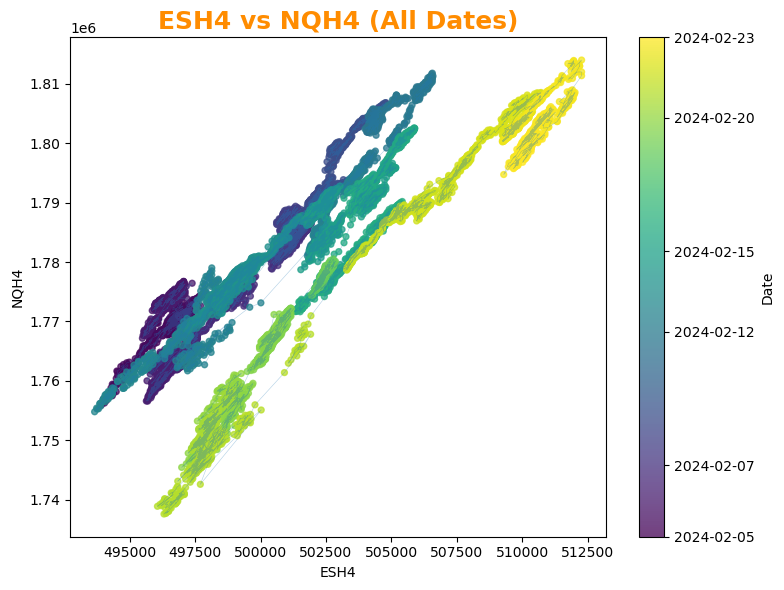

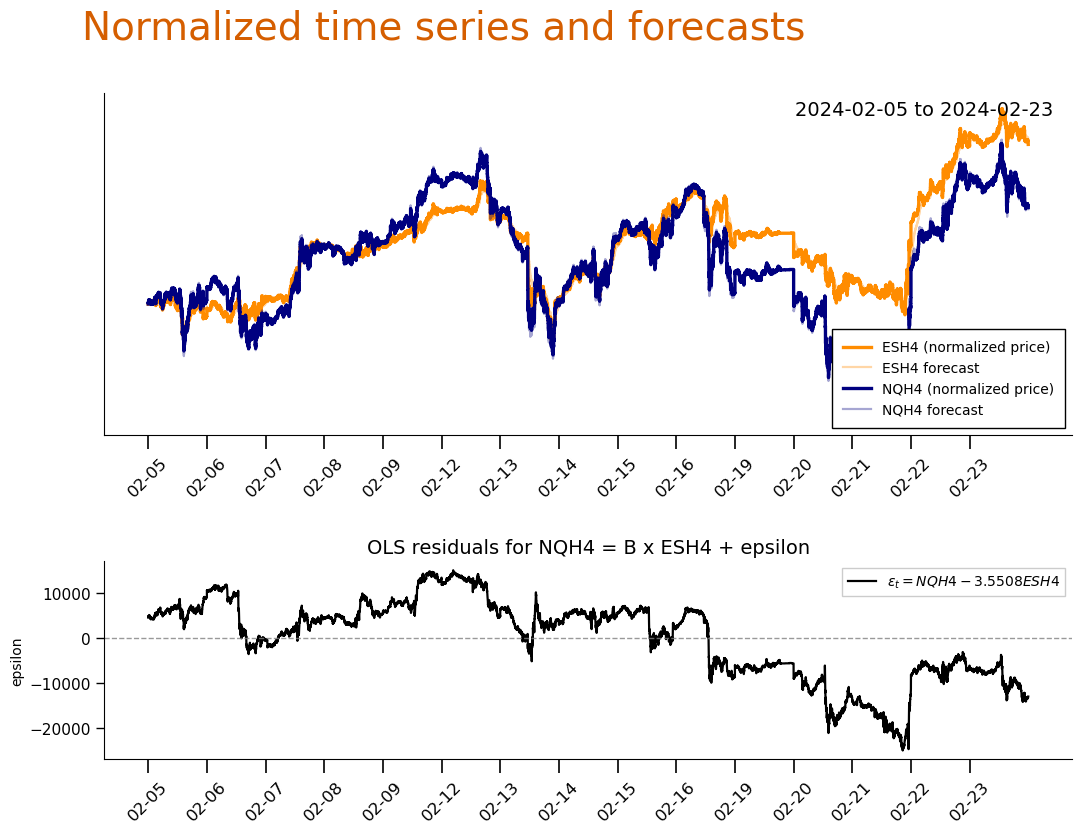

In [150]:
sym_active, df_mid_all, df_state_all = run_multiday_pipeline_concat(
    db,
    start_date="2024-02-01",
    end_date="2024-02-29",
    insts=("ES", "NQ"),
)

df_2 = build_discrete_2asset_input(
    df_state_all,
    col_a="ESH4",
    col_b="NQH4",
)

mean_daily_pnl_$         10908.333333
max_drawdown_daily_$   -333625.000000
dtype: float64


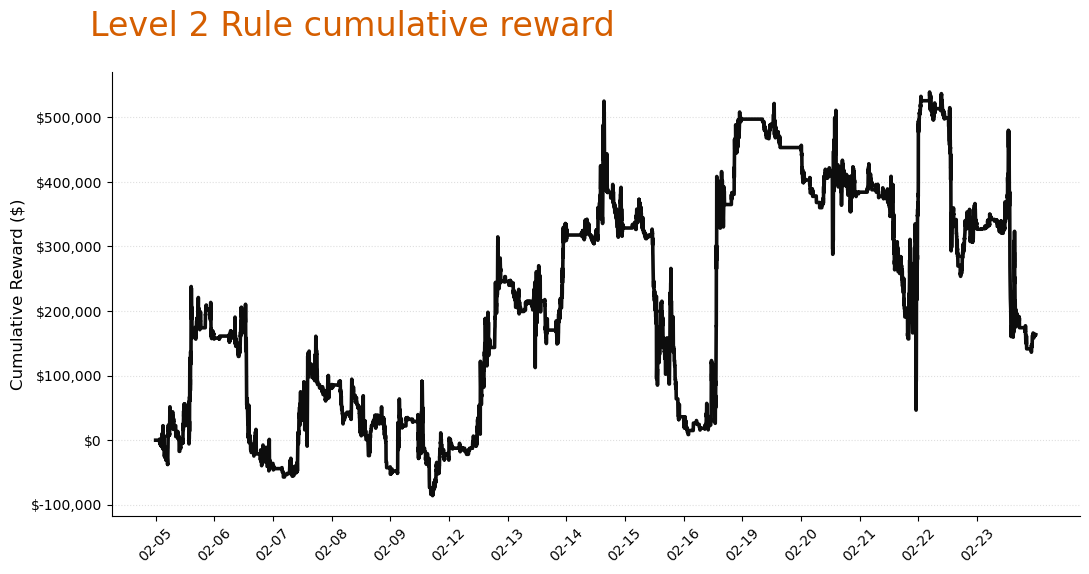

In [180]:
out_rule_2 = run_rule_2asset_discrete(
    df_2,
    col_a="ESH4",
    col_b="NQH4",
    mult_a=50.0,
    mult_b=20.0,
)
print(pd.Series(out_rule_2["metrics"]))
plot_trading_time_cum(out_rule_2["cum"], "Level 2 Rule cumulative reward")

State Updated Version:

We extend the Q-learning pair trading model by adding a regime-aware state variable that measures the recent reliability of the cointegration signal. Specifically, we define a rolling signal-confidence score
$
c_t = \frac{1}{W}\sum_{j=1}^{W} \text{sign}(signal_{t-j-1})\cdot \text{sign}(r_{t-j}),
$
which uses only past information and introduces no forward-looking bias. We then discretize this score via its sign into a binary variable $\text{sign}(c_t) \in {-1, 1}$, where $+1$ indicates the signal has been working and $-1$ indicates it has been failing. This regime variable is added to the state, allowing the agent to distinguish between stable mean-reversion regimes and regime shifts.

Importantly, the reward function remains unchanged and is given by
Use this format:

$
R_t = \mathrm{PnL}t - \mathrm{cost}_{t} - \mathrm{inventory}_{penalty}$

so the only modification to the model is the inclusion of the regime variable in the state representation.


In [ ]:
def train_q_learning_2asset_discrete_adaptive(
    df: pd.DataFrame,
    *,
    col_a: str,
    col_b: str,
    sig_a: str = "sig_a",
    sig_b: str = "sig_b",
    train_end: str = "2024-02-15",
    inv_limit: int = 2,
    action_values=(-2, -1, 0, 1, 2),
    gamma: float = 0.99,
    lr: float = 0.05,
    epochs: int = 80,
    eps_start: float = 0.20,
    eps_end: float = 0.05,
    seed: int = 0,
    z_window: int = 300,
    z_min_periods: int | None = None,
    z_lag: int = 1,
    z_step: float = 0.5,
    z_clip: float | None = 5.0,
    mult_a: float = 50,
    mult_b: float = 20,
    cost_per_trade: float = 0.0,
    inv_penalty: float = 0.1,
    regime_window: int = 60,
    q_decay: float = 0.998,
    use_adaptive_lr: bool = False,
    lr_visit_scale: float = 0.01,
    reset_every: int | None = None,
    persistent_exploration: float = 0.02,
):
    rng = np.random.default_rng(seed)
    df = df.sort_index().copy()

    train_mask = df.index <= pd.Timestamp(train_end)
    test_mask = ~train_mask
    if train_mask.sum() < 200:
        raise ValueError("Training set too small.")
    if test_mask.sum() < 200:
        raise ValueError("Test set too small.")

    Pa = df[col_a].astype(float)
    Pb = df[col_b].astype(float)

    za, _, _ = make_walkforward_zscore(
        df[sig_a], window=z_window, min_periods=z_min_periods, lag=z_lag
    )
    zb, _, _ = make_walkforward_zscore(
        df[sig_b], window=z_window, min_periods=z_min_periods, lag=z_lag
    )

    dPa_next = (Pa.shift(-1) - Pa).iloc[:-1]
    dPb_next = (Pb.shift(-1) - Pb).iloc[:-1]
    idx = df.index[:-1]

    def quantize_z(zs: pd.Series) -> pd.Series:
        vals = zs.iloc[:-1].astype(float).values
        out = np.empty(len(vals), dtype=float)
        for i, v in enumerate(vals):
            if not np.isfinite(v):
                out[i] = 0.0
                continue
            if z_clip is not None:
                v = float(np.clip(v, -z_clip, z_clip))
            out[i] = float(z_step * np.round(v / z_step))
        return pd.Series(out, index=idx, dtype=float)

    def quantize_conf_sign(x: pd.Series) -> pd.Series:
        vals = x.astype(float).values
        out = np.zeros(len(vals), dtype=int)
        for i, v in enumerate(vals):
            if not np.isfinite(v):
                out[i] = 0
            elif v > 0:
                out[i] = 1
            elif v < 0:
                out[i] = -1
            else:
                out[i] = 0
        return pd.Series(out, index=x.index, dtype=int)

    zqa = quantize_z(za)
    zqb = quantize_z(zb)

    # ---------------------------------------------------------
    # Regime / signal-confidence state:
    # sign(signal_{t-1}) * sign(return_t), then rolling mean.
    # Finally compress to {-1, 0, 1}.
    # ---------------------------------------------------------
    eff_a = np.sign(za.shift(1).iloc[:-1]) * np.sign(dPa_next)
    eff_b = np.sign(zb.shift(1).iloc[:-1]) * np.sign(dPb_next)

    c_a = (
        eff_a.rolling(regime_window, min_periods=1)
        .mean()
        .fillna(0.0)
    )
    c_b = (
        eff_b.rolling(regime_window, min_periods=1)
        .mean()
        .fillna(0.0)
    )

    cqa = quantize_conf_sign(c_a)
    cqb = quantize_conf_sign(c_b)

    one_dim = np.array(sorted(set(int(a) for a in action_values)), dtype=int)
    joint_actions = [(a, b) for a in one_dim for b in one_dim]
    n_actions = len(joint_actions)

    Q = {}
    N = defaultdict(int)

    train_mask_rl = train_mask[:-1]
    train_idx = np.where(train_mask_rl)[0]
    train_start, train_end_i = int(train_idx[0]), int(train_idx[-1])

    for ep in range(epochs):
        if reset_every is not None and ep > 0 and (ep % reset_every == 0):
            Q = {}
            N = defaultdict(int)

        eps_sched = eps_start + (eps_end - eps_start) * (ep / max(1, epochs - 1))
        eps = max(eps_end, eps_sched) + persistent_exploration

        na_prev, nb_prev = 0, 0

        for k in range(train_start, train_end_i + 1):
            s_t = (
                float(zqa.iloc[k]),   # signal A
                float(zqb.iloc[k]),   # signal B
                int(cqa.iloc[k]),     # regime A in {-1,0,1}
                int(cqb.iloc[k]),     # regime B in {-1,0,1}
                int(na_prev),         # inventory A
                int(nb_prev),         # inventory B
            )

            if rng.random() < eps:
                a_idx = int(rng.integers(0, n_actions))
            else:
                q_vals = np.array([Q.get((s_t, j), 0.0) for j in range(n_actions)])
                a_idx = int(np.argmax(q_vals))

            a_a, a_b = joint_actions[a_idx]
            n_a = clip_int(na_prev + a_a, -inv_limit, inv_limit)
            n_b = clip_int(nb_prev + a_b, -inv_limit, inv_limit)

            dn_a = n_a - na_prev
            dn_b = n_b - nb_prev

            dPa = float(dPa_next.iloc[k])
            dPb = float(dPb_next.iloc[k])

            gross = n_a * dPa * mult_a + n_b * dPb * mult_b
            trade_cost = cost_per_trade * (abs(dn_a) + abs(dn_b))
            inventory_cost = inv_penalty * (n_a**2 + n_b**2)
            pnl = gross - trade_cost
            R = pnl - inventory_cost

            if k == train_end_i:
                td_target = R
            else:
                s_next = (
                    float(zqa.iloc[k + 1]),
                    float(zqb.iloc[k + 1]),
                    int(cqa.iloc[k + 1]),
                    int(cqb.iloc[k + 1]),
                    int(n_a),
                    int(n_b),
                )
                q_next = np.array([Q.get((s_next, j), 0.0) for j in range(n_actions)])
                td_target = R + gamma * float(np.max(q_next))

            q_old = Q.get((s_t, a_idx), 0.0)
            N[(s_t, a_idx)] += 1
            lr_eff = (
                lr / (1.0 + lr_visit_scale * N[(s_t, a_idx)])
                if use_adaptive_lr else lr
            )
            Q[(s_t, a_idx)] = q_decay * q_old + lr_eff * (td_target - q_old)

            na_prev, nb_prev = n_a, n_b

    def greedy_run(mask_np):
        ks = np.where(mask_np[:-1])[0]
        na_prev, nb_prev = 0, 0

        dates, pnl_list, reward_list = [], [], []
        n_a_list, n_b_list = [], []
        act_a, act_b = [], []

        for k in ks:
            s_t = (
                float(zqa.iloc[k]),
                float(zqb.iloc[k]),
                int(cqa.iloc[k]),
                int(cqb.iloc[k]),
                int(na_prev),
                int(nb_prev),
            )
            q_vals = np.array([Q.get((s_t, j), 0.0) for j in range(n_actions)])
            a_a, a_b = joint_actions[int(np.argmax(q_vals))]

            n_a = clip_int(na_prev + a_a, -inv_limit, inv_limit)
            n_b = clip_int(nb_prev + a_b, -inv_limit, inv_limit)

            dn_a = n_a - na_prev
            dn_b = n_b - nb_prev

            dPa = float(dPa_next.iloc[k])
            dPb = float(dPb_next.iloc[k])

            gross = n_a * dPa * mult_a + n_b * dPb * mult_b
            trade_cost = cost_per_trade * (abs(dn_a) + abs(dn_b))
            inventory_cost = inv_penalty * (n_a**2 + n_b**2)
            pnl = gross - trade_cost
            reward = pnl - inventory_cost

            dates.append(idx[k])
            pnl_list.append(pnl)
            reward_list.append(reward)
            n_a_list.append(n_a)
            n_b_list.append(n_b)
            act_a.append(a_a)
            act_b.append(a_b)

            na_prev, nb_prev = n_a, n_b

        dt = pd.DatetimeIndex(dates)
        pnl_s = pd.Series(pnl_list, index=dt, name="pnl_$")
        reward_s = pd.Series(reward_list, index=dt, name="reward_$")
        n_df = pd.DataFrame(
            {
                f"n_{col_a}": n_a_list,
                f"n_{col_b}": n_b_list,
            },
            index=dt,
        )
        actions_df = pd.DataFrame(
            {
                f"a_{col_a}": act_a,
                f"a_{col_b}": act_b,
            },
            index=dt,
        )
        return pnl_s, reward_s, pnl_s.cumsum(), reward_s.cumsum(), n_df, actions_df

    tr_pnl, tr_reward, tr_cum_pnl, tr_cum_reward, tr_n, tr_act = greedy_run(train_mask)
    te_pnl, te_reward, te_cum_pnl, te_cum_reward, te_n, te_act = greedy_run(test_mask)

    return {
        "Q": Q,
        "joint_actions": joint_actions,
        "train_pnl": tr_pnl,
        "train_reward": tr_reward,
        "train_cum": tr_cum_reward,
        "train_cum_pnl": tr_cum_pnl,
        "train_n": tr_n,
        "train_actions": tr_act,
        "test_pnl": te_pnl,
        "test_reward": te_reward,
        "test_cum": te_cum_reward,
        "test_cum_pnl": te_cum_pnl,
        "test_n": te_n,
        "test_actions": te_act,
        "signal_confidence_a": c_a,
        "signal_confidence_b": c_b,
        "regime_state_a": cqa,
        "regime_state_b": cqb,
        "state_info": {
            "state_definition": "(zqa, zqb, regime_a, regime_b, na_prev, nb_prev)",
            "z_values": "quantized by z_step and clipped by z_clip",
            "regime_values": [-1, 0, 1],
            "inventory_values": list(range(-inv_limit, inv_limit + 1)),
        },
        "metrics": { ... },
    }
out_rl_2 = train_q_learning_2asset_discrete_adaptive(
    df_2,
    col_a="ESH4",
    col_b="NQH4",
    train_end="2024-02-19",
    mult_a=50.0,
    mult_b=20.0,
    epochs=100,
    eps_start=0.5,
    eps_end=0.01,
    inv_penalty=1,
    z_step=0.5,
    lr=0.001,
    regime_window=60,
)

{'train_mean_daily_pnl_$': 2262170.4545454546, 'train_max_drawdown_$': 0.0, 'test_mean_daily_pnl_$': 788275.0, 'test_max_drawdown_$': 0.0}


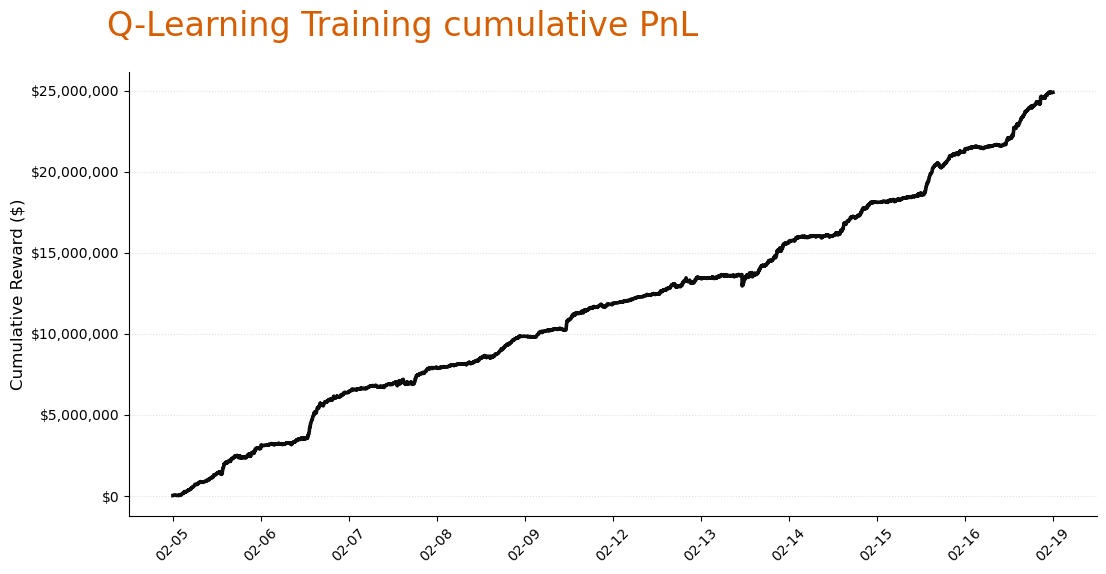

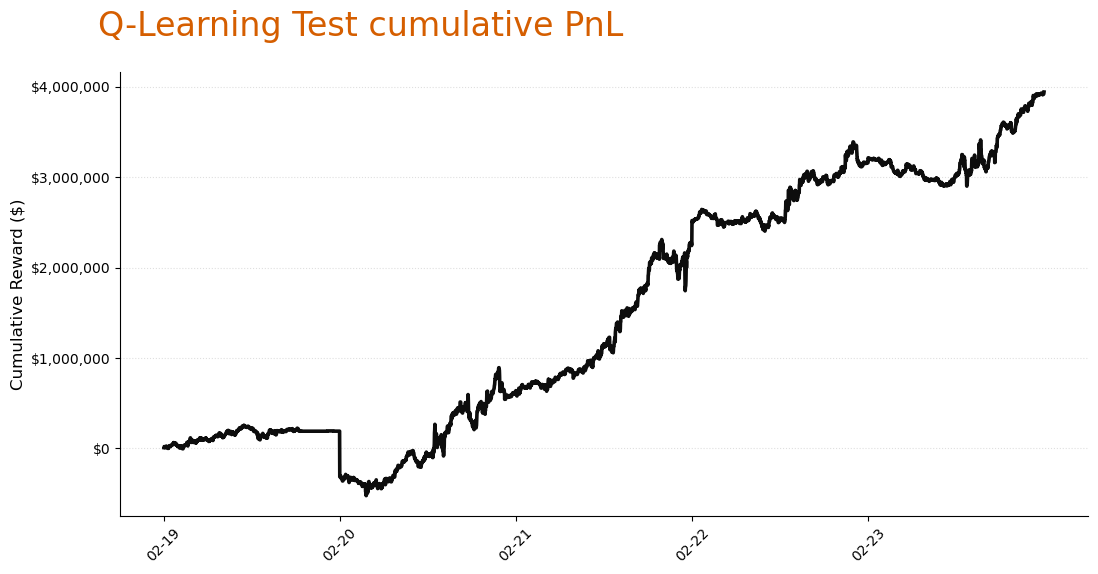

In [184]:
print({
    "train_mean_daily_pnl_$": mean_daily_pnl(out_rl_2["train_pnl"]),
    "train_max_drawdown_$": max_daily_drawdown(out_rl_2["train_pnl"]),
    "test_mean_daily_pnl_$": mean_daily_pnl(out_rl_2["test_pnl"]),
    "test_max_drawdown_$": max_daily_drawdown(out_rl_2["test_pnl"]),
})

plot_trading_time_cum(out_rl_2["train_cum_pnl"], "Q-Learning Training cumulative PnL")
plot_trading_time_cum(out_rl_2["test_cum_pnl"],  "Q-Learning Test cumulative PnL")


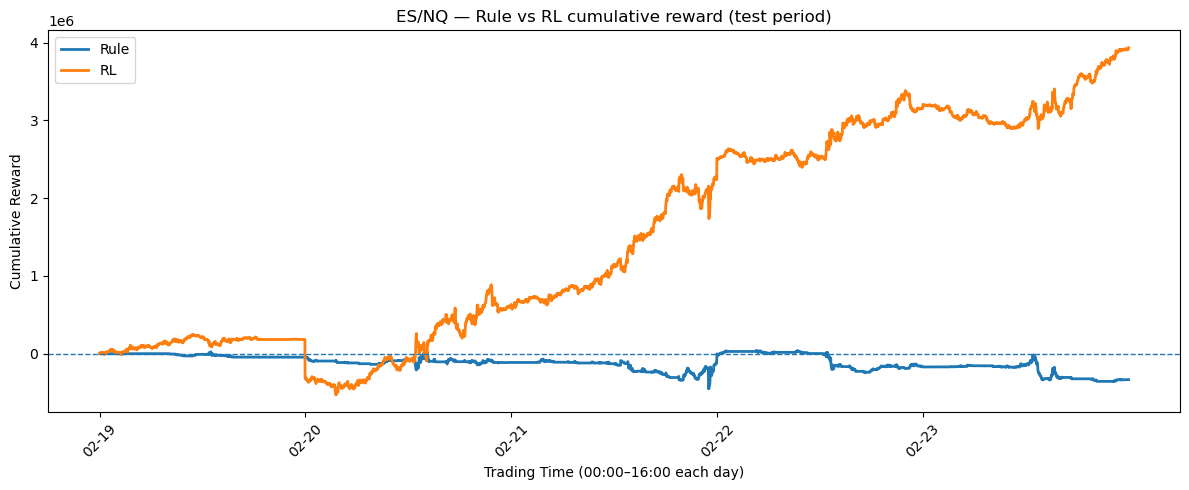

In [185]:
train_end = "2024-02-19"

rule_cum = out_rule_2["cum"]
rl_cum   = out_rl_2["test_cum_pnl"]

# restrict rule to the test period and re-zero so both start at 0
rule_test = rule_cum[rule_cum.index > pd.Timestamp(train_end)].copy()
rule_test = rule_test - rule_test.iloc[0]
rl_test   = rl_cum - rl_cum.iloc[0]

# trading-time x-axis so overnight gaps don't stretch the plot
aligned = pd.concat(
    [rule_test.rename("Rule"), rl_test.rename("RL")], axis=1
).dropna(how="all")

x = np.arange(len(aligned))
dates = aligned.index.normalize()
unique_dates, first_pos = np.unique(dates.values, return_index=True)
unique_dates = pd.to_datetime(unique_dates)

plt.figure(figsize=(12, 5))
plt.plot(x, aligned["Rule"].values, label="Rule", linewidth=2)
plt.plot(x, aligned["RL"].values,   label="RL",   linewidth=2)
plt.axhline(0, linestyle="--", linewidth=1)
plt.xticks(first_pos, [d.strftime("%m-%d") for d in unique_dates], rotation=45)
plt.xlabel("Trading Time (00:00–16:00 each day)")
plt.ylabel("Cumulative Reward")
plt.title("ES/NQ — Rule vs RL cumulative reward (test period)")
plt.legend()
plt.tight_layout()
plt.show()

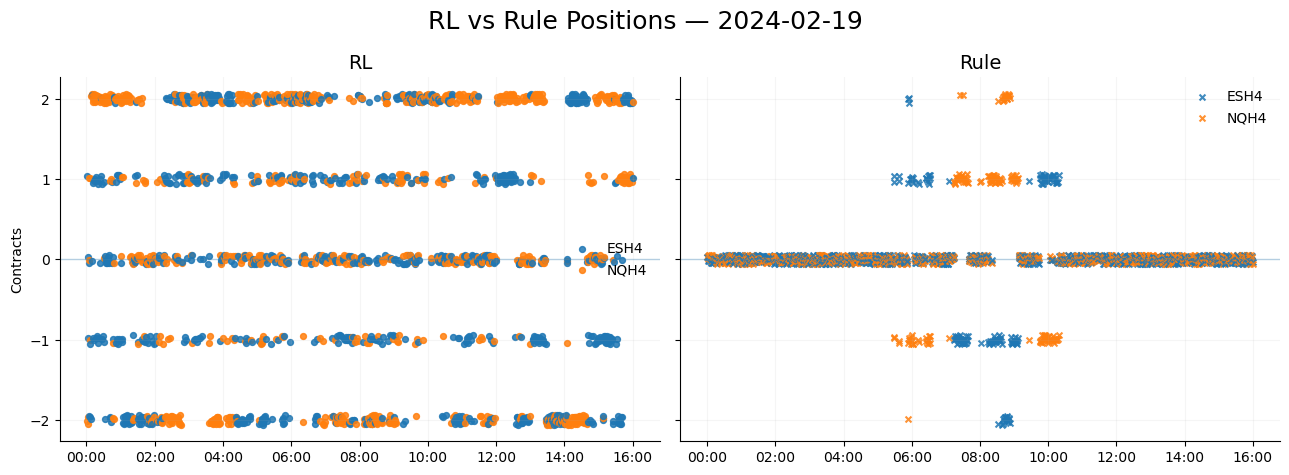

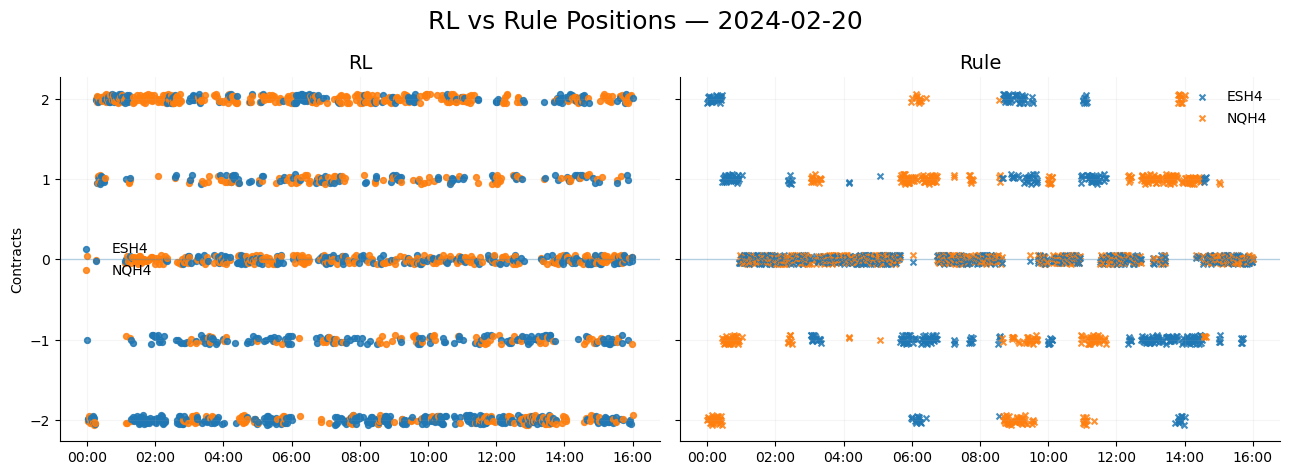

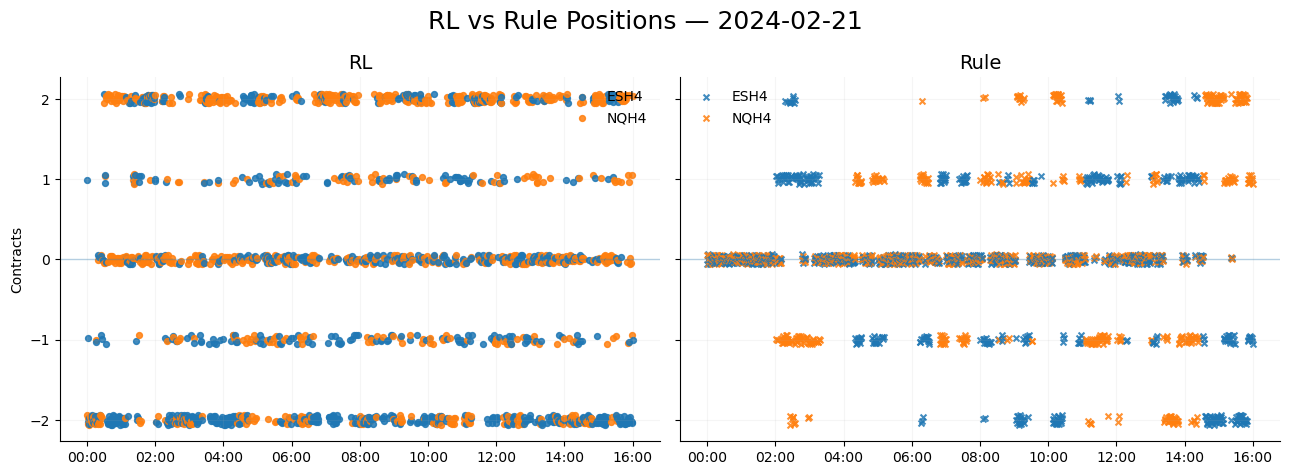

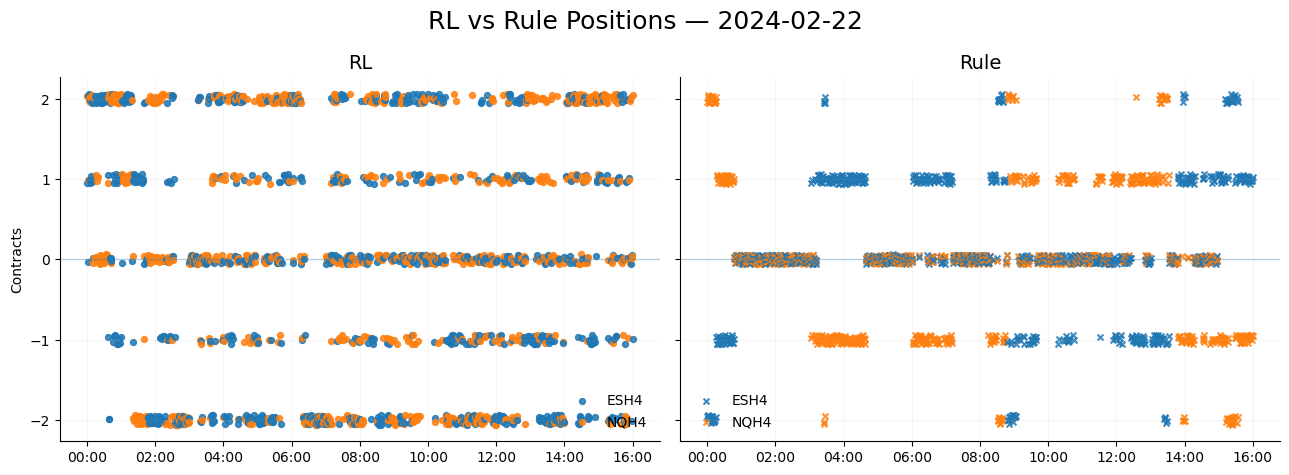

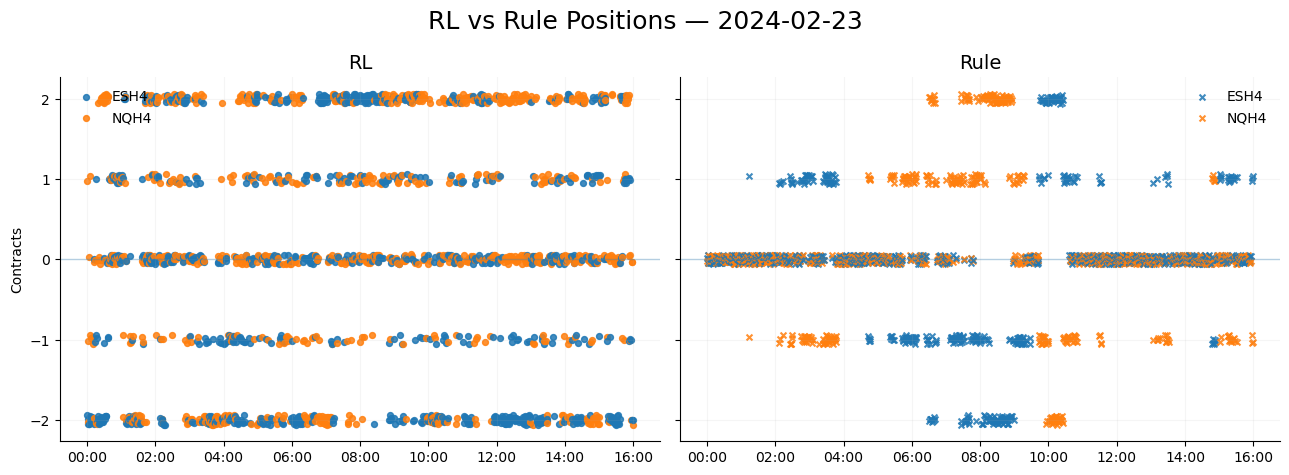

In [186]:
def _scatter_positions_with_overlap_control(
    ax,
    df_day: pd.DataFrame,
    asset_specs,
    *,
    marker="o",
    dot_size=18,
    alpha=0.85,
    jitter=0.06,
    rng=None,
):
    """
    Plot one day of positions with overlap control.

    asset_specs: list of tuples
        [(column_name, label, color), ...]
    """

    if rng is None:
        rng = np.random.default_rng(0)

    # loop over timestamps, not assets
    for ts, row in df_day.iterrows():
        order = rng.permutation(len(asset_specs))

        for idx in order:
            col_name, label, color = asset_specs[idx]
            y = float(row[col_name])

            # tiny vertical jitter so overlapping dots become visible
            y_plot = y + rng.uniform(-jitter, jitter)

            ax.scatter(
                ts,
                y_plot,
                s=dot_size,
                alpha=alpha,
                marker=marker,
                color=color,
            )

    # add legend manually once
    handles = []
    for _, label, color in asset_specs:
        h = ax.scatter([], [], s=dot_size, color=color, alpha=alpha, marker=marker, label=label)
        handles.append(h)

    return handles


def plot_rl_vs_rule_side_by_side_2asset(
    out_rl,
    out_rule,
    *,
    col_a: str,
    col_b: str,
    leg: str = "test",
    trading_start: str = "00:00",
    trading_end: str = "16:00",
    dot_size: int = 18,
    alpha: float = 0.85,
    jitter: float = 0.06,
    seed: int = 0,
):
    """
    Compare RL vs Rule positions side by side for a 2-asset strategy.

    Fixes overlap by:
    1) randomizing plotting order at each timestamp
    2) adding tiny vertical jitter
    """

    rng = np.random.default_rng(seed)

    n_a_col = f"n_{col_a}"
    n_b_col = f"n_{col_b}"

    rl_key = f"{leg}_n"
    if rl_key not in out_rl:
        raise ValueError(f"Missing key '{rl_key}' in out_rl.")
    if "n" not in out_rule:
        raise ValueError("Missing key 'n' in out_rule.")

    df_rl = out_rl[rl_key][[n_a_col, n_b_col]].dropna().copy()
    df_rule = out_rule["n"][[n_a_col, n_b_col]].dropna().copy()

    # trading-hours filter
    t0 = pd.to_datetime(trading_start).time()
    t1 = pd.to_datetime(trading_end).time()

    df_rl = df_rl[(df_rl.index.time >= t0) & (df_rl.index.time <= t1)]
    df_rule = df_rule[(df_rule.index.time >= t0) & (df_rule.index.time <= t1)]

    common_days = sorted(
        set(df_rl.index.normalize().unique()).intersection(
            set(df_rule.index.normalize().unique())
        )
    )

    if not common_days:
        print("No common days to plot.")
        return

    asset_specs = [
        (n_a_col, col_a, "tab:blue"),
        (n_b_col, col_b, "tab:orange"),
    ]

    for day in common_days:
        g_rl = df_rl[df_rl.index.normalize() == day]
        g_rule = df_rule[df_rule.index.normalize() == day]

        if g_rl.empty and g_rule.empty:
            continue

        fig, axes = plt.subplots(
            1, 2, figsize=(13, 4.8), sharey=True, facecolor="white"
        )

        fig.suptitle(
            f"RL vs Rule Positions — {pd.to_datetime(day).strftime('%Y-%m-%d')}",
            fontsize=18,
            y=0.98,
        )

        # ---------------- RL panel ----------------
        ax = axes[0]
        handles = _scatter_positions_with_overlap_control(
            ax,
            g_rl,
            asset_specs,
            marker="o",
            dot_size=dot_size,
            alpha=alpha,
            jitter=jitter,
            rng=rng,
        )

        ax.set_title("RL", fontsize=14)
        ax.axhline(0, linewidth=1, alpha=0.3)
        ax.set_ylabel("Contracts")
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
        ax.grid(alpha=0.12)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.legend(handles=handles, frameon=False)

        # ---------------- Rule panel ----------------
        ax = axes[1]
        handles = _scatter_positions_with_overlap_control(
            ax,
            g_rule,
            asset_specs,
            marker="x",
            dot_size=dot_size,
            alpha=alpha,
            jitter=jitter,
            rng=rng,
        )

        ax.set_title("Rule", fontsize=14)
        ax.axhline(0, linewidth=1, alpha=0.3)
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
        ax.grid(alpha=0.12)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.legend(handles=handles, frameon=False)

        plt.tight_layout()
        plt.show()


plot_rl_vs_rule_side_by_side_2asset(
    out_rl=out_rl_2,
    out_rule=out_rule_2,
    col_a="ESH4",
    col_b="NQH4",
    leg="test",
    trading_start="00:00",
    trading_end="16:00",
    seed=42,
)

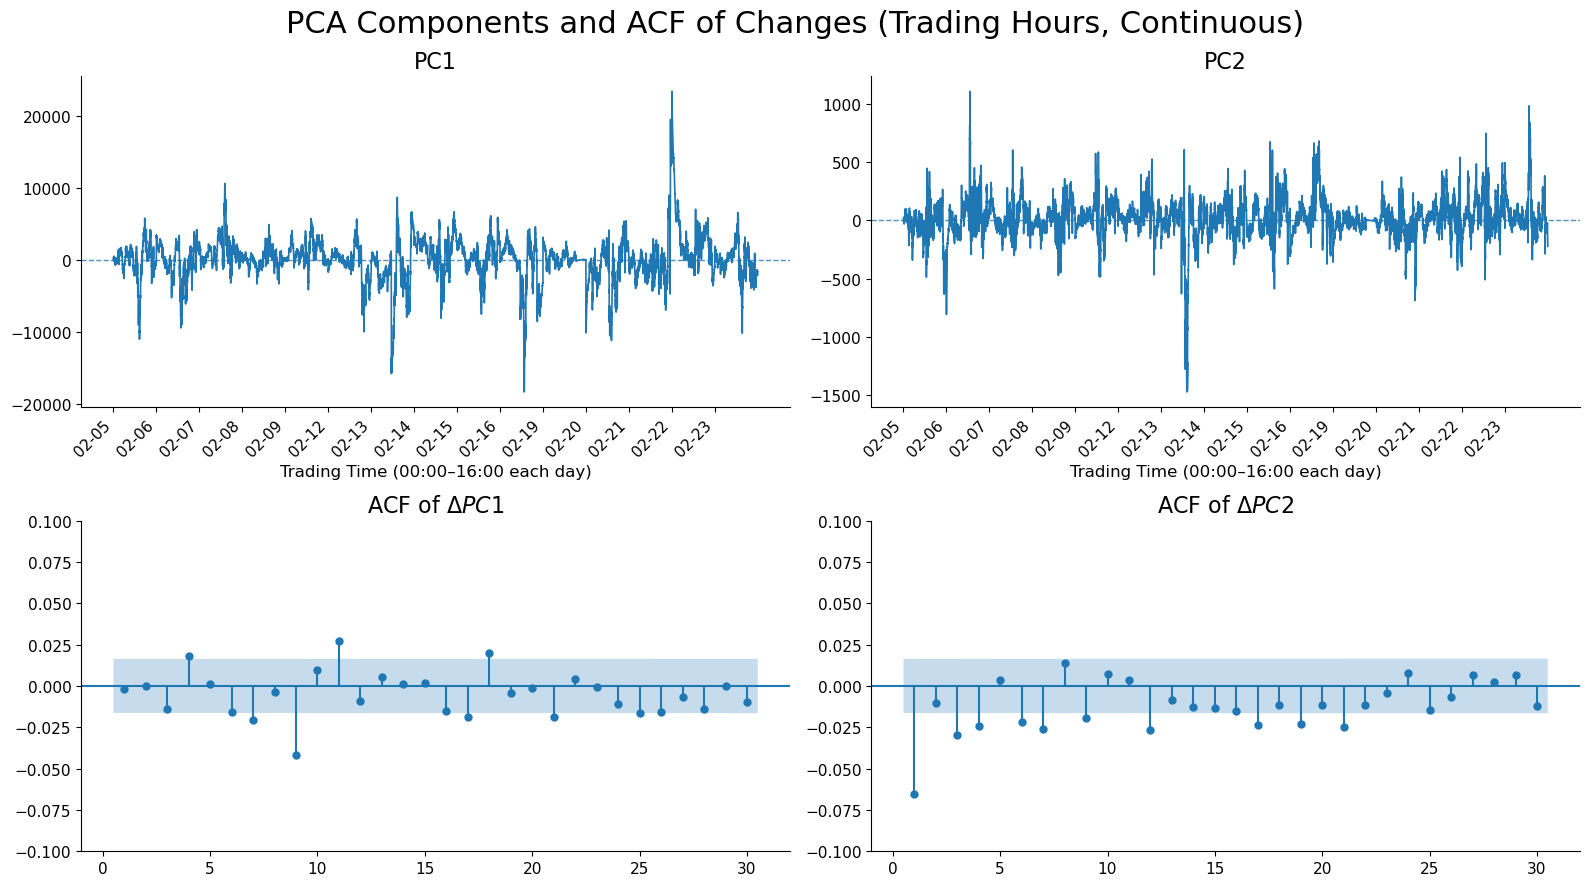

In [187]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf


def plot_pc_and_acf_trading_hours_cts(
    df: pd.DataFrame,
    pc1_col: str = "pc1",
    pc2_col: str = "pc2",
    nlags: int = 30,
    acf_ylim: tuple = (-0.10, 0.10),
    start_time: str = "00:00",
    end_time: str = "16:00",
):
    out = df.copy()

    if not isinstance(out.index, pd.DatetimeIndex):
        raise ValueError("DataFrame index must be a DatetimeIndex.")

    # keep only trading hours
    out = out.between_time(start_time, end_time).copy()

    pc1 = out[pc1_col].astype(float)
    pc2 = out[pc2_col].astype(float)

    dpc1 = pc1.diff().dropna()
    dpc2 = pc2.diff().dropna()

    # continuous x-axis after filtering trading hours
    x = np.arange(len(out))

    fig, axes = plt.subplots(2, 2, figsize=(16, 9), facecolor="white")
    fig.suptitle("PCA Components and ACF of Changes (Trading Hours, Continuous)", fontsize=22, y=0.98)

    # PC1
    axes[0, 0].plot(x, pc1.values, linewidth=1.2, color="tab:blue")
    axes[0, 0].axhline(0, linestyle="--", linewidth=1.0, color="tab:blue", alpha=0.8)
    axes[0, 0].set_title("PC1", fontsize=16)

    # PC2
    axes[0, 1].plot(x, pc2.values, linewidth=1.2, color="tab:blue")
    axes[0, 1].axhline(0, linestyle="--", linewidth=1.0, color="tab:blue", alpha=0.8)
    axes[0, 1].set_title("PC2", fontsize=16)

    # day-start tick positions without using DatetimeIndex.shift()
    day_vals = out.index.normalize().values
    day_start_pos = np.r_[0, np.flatnonzero(day_vals[1:] != day_vals[:-1]) + 1]
    day_start_labels = [out.index[i].strftime("%m-%d") for i in day_start_pos]

    for ax in axes[0]:
        ax.set_xticks(day_start_pos)
        ax.set_xticklabels(day_start_labels, rotation=45, ha="right")
        ax.set_xlabel("Trading Time (00:00–16:00 each day)", fontsize=12)

    # ACF of changes
    plot_acf(dpc1, lags=nlags, ax=axes[1, 0], zero=False)
    axes[1, 0].set_title(r"ACF of $\Delta PC1$", fontsize=16)
    axes[1, 0].set_ylim(acf_ylim)

    plot_acf(dpc2, lags=nlags, ax=axes[1, 1], zero=False)
    axes[1, 1].set_title(r"ACF of $\Delta PC2$", fontsize=16)
    axes[1, 1].set_ylim(acf_ylim)

    for ax in axes.ravel():
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.tick_params(labelsize=11)

    plt.tight_layout()
    plt.show()

    return pd.DataFrame(
        {
            "PC1": pc1,
            "PC2": pc2,
            "dPC1": pc1.diff(),
            "dPC2": pc2.diff(),
        },
        index=out.index,
    )

res = plot_pc_and_acf_trading_hours_cts(
    df_state_all,
    pc1_col="pc1",
    pc2_col="pc2",
    nlags=30,
    acf_ylim=(-0.10, 0.10),
)

## PC1 is stationary (ADF strongly rejects unit root) but shows high autocorrelation (slowly decaying ACF).

best horizon h* = 2   corr(signal, fwd_ret) = 0.0007


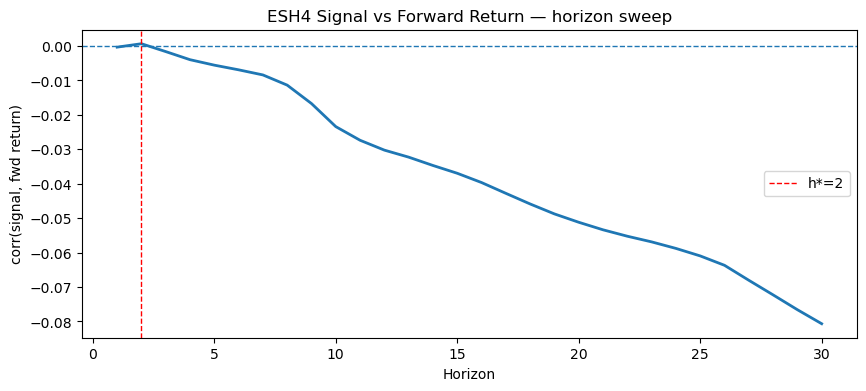

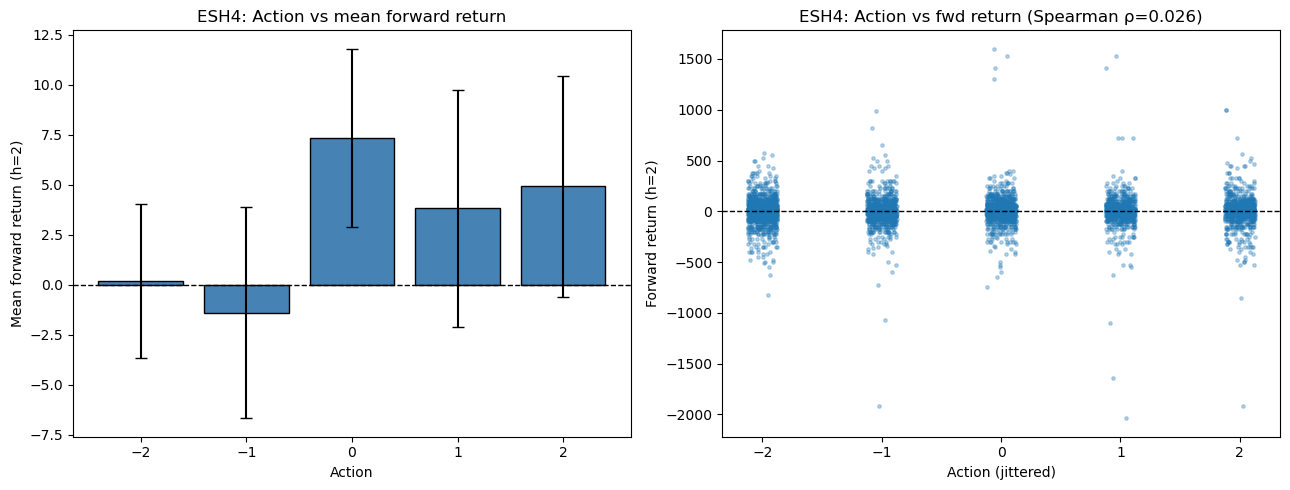

In [188]:
# ============================================================
# 1) Find best horizon for signal vs forward return
# ============================================================

def signal_fwd_corr(df, signal_col, price_col, horizon,
                   start_date="2024-02-19"):
    d = df.sort_index().between_time("00:00", "16:00")
    d = d[d.index >= pd.Timestamp(start_date)]

    s = d[signal_col].astype(float)
    fwd = d[price_col].shift(-horizon) - d[price_col]

    both = pd.concat([s.rename("s"), fwd.rename("r")], axis=1).dropna()
    if both.empty:
        return np.nan

    return both["s"].corr(both["r"])


horizons = range(1, 31)

corrs = np.array([
    signal_fwd_corr(df_2, "sig_a", "ESH4", h) for h in horizons
], dtype=float)

best_idx = int(np.nanargmax(corrs))
best_h   = list(horizons)[best_idx]
best_c   = corrs[best_idx]

print(f"best horizon h* = {best_h}   corr(signal, fwd_ret) = {best_c:.4f}")

plt.figure(figsize=(10,4))
plt.plot(list(horizons), corrs, linewidth=2)
plt.axhline(0, ls="--", lw=1)
plt.axvline(best_h, ls="--", lw=1, color="red", label=f"h*={best_h}")
plt.xlabel("Horizon")
plt.ylabel("corr(signal, fwd return)")
plt.title("ESH4 Signal vs Forward Return — horizon sweep")
plt.legend()
plt.show()


# ============================================================
# 2) Plot action vs forward return at best horizon
# ============================================================

def action_vs_fwd_return(df, price_col, action, horizon,
                        start_date="2024-02-19"):
    d = df.sort_index().between_time("00:00", "16:00")
    d = d[d.index >= pd.Timestamp(start_date)]

    fwd = (d[price_col].shift(-horizon) - d[price_col]).rename("fwd_ret")

    a = action.sort_index().astype(float)
    a = a.between_time("00:00", "16:00")
    a = a[a.index >= pd.Timestamp(start_date)]
    a.name = "action"

    return pd.concat([a, fwd], axis=1).dropna()


# use ES actions
action_ES = out_rl_2["test_actions"]["a_ESH4"]

af = action_vs_fwd_return(df_2, "ESH4", action_ES, best_h)


# Spearman correlation
rho, pval = spearmanr(af["action"], af["fwd_ret"])


# ---- group stats (MISSING PART FIXED) ----
grp = af.groupby("action")["fwd_ret"].agg(
    mean="mean",
    std="std",
    count="count"
)


# ============================================================
# Plot
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# (a) mean fwd return per action bucket
axes[0].bar(
    grp.index.astype(int),
    grp["mean"],
    yerr=grp["std"] / np.sqrt(grp["count"]),
    capsize=4,
    color="steelblue",
    edgecolor="black"
)

axes[0].axhline(0, ls="--", lw=1, color="k")
axes[0].set_xlabel("Action")
axes[0].set_ylabel(f"Mean forward return (h={best_h})")
axes[0].set_title("ESH4: Action vs mean forward return")

# (b) scatter
jitter = (np.random.rand(len(af)) - 0.5) * 0.25

axes[1].scatter(
    af["action"] + jitter,
    af["fwd_ret"],
    s=6,
    alpha=0.3
)

axes[1].axhline(0, ls="--", lw=1, color="k")
axes[1].set_xlabel("Action (jittered)")
axes[1].set_ylabel(f"Forward return (h={best_h})")
axes[1].set_title(f"ESH4: Action vs fwd return (Spearman ρ={rho:.3f})")

plt.tight_layout()
plt.show()

### When the signal becomes more predictive, the RL policy tends to follow it more.

In [199]:
import numpy as np
import pandas as pd


def summarize_pnl_by_regime(
    *,
    pnl: pd.Series,
    regime_state: pd.Series,
    start_date: str = "2024-02-19",
    trading_start: str = "00:00",
    trading_end: str = "16:00",
    annualization: float = 252.0,
):
    # align
    tmp = pd.DataFrame({
        "pnl": pnl.sort_index().astype(float),
        "regime": regime_state.sort_index(),
    })

    tmp = tmp[tmp.index >= pd.Timestamp(start_date)]
    tmp = tmp.between_time(trading_start, trading_end)
    tmp = tmp.dropna()
    tmp = tmp[tmp["regime"].isin([-1, 1])]

    def sharpe(x):
        if len(x) < 2 or x.std(ddof=1) == 0:
            return np.nan
        return np.sqrt(annualization) * x.mean() / x.std(ddof=1)

    results = {}

    for reg, name in [(1, "works (+1)"), (-1, "fails (-1)")]:
        sub = tmp[tmp["regime"] == reg]["pnl"]

        results[name] = {
            "cum_pnl": sub.sum(),
            "sharpe": sharpe(sub),
            "N": len(sub),
        }

    return pd.DataFrame(results).T

summary = summarize_pnl_by_regime(
    pnl=out_rl_2["test_pnl"],
    regime_state=out_rl_2["regime_state_a"],
    start_date="2024-02-19",
    trading_start="00:00",
    trading_end="16:00",
)

print(summary)

              cum_pnl    sharpe       N
works (+1)  3359625.0  1.194198  2542.0
fails (-1)  1352750.0  0.604387  1821.0
